# **TUGAS KELOMPOK DATA WRANGLING**
### **Pre-Processing dan Klasifikasi Data Pasien ICU untuk Prediksi Kelangsungan Hidup** 

### A. Deskripsi Dataset
Dataset yang digunakan adalah ICU Survival Prediction dari kompetisi Kaggle ML League 2026 Task 2. Dataset berisi data tabular pasien yang dirawat di ICU (Intensive Care Unit) dan digunakan untuk memprediksi apakah seorang pasien selamat atau tidak selamat selama perawatan. Kompetisi menggambarkannya sebagai data rumah sakit yang berantakan dengan hasil laboratorium yang hilang, sehingga cocok untuk latihan data wrangling.

File yang digunakan: train (6).csv

Ukuran data: 4.580 baris (pasien) dan 16 kolom.

Variabel target: survived_icu (0 = pasien tidak selamat, 1 = pasien selamat). Karena hanya ada dua kelas, ini adalah masalah klasifikasi biner.

Karakteristik data:

- Terdapat missing value pada 5 kolom: wbc_count, creatinine, bmi, oxygen_saturation, dan respiratory_rate.
- Terdapat baris duplikat yang ditandai ID berawalan ICU_DUP_.
- Terdapat nilai ekstrem yang tidak wajar secara medis (misalnya denyut jantung di atas 1.200) dan ketidakkonsistenan tekanan darah (sistolik lebih kecil dari diastolik).
- Kelas target tidak seimbang ringan: sekitar 64,5% pasien selamat dan 35,5% tidak selamat (setelah cleaning).

Dataset yang digunakan adalah file:

train (6).csv 

Memiliki: 
1. 4.580 baris
2. 16 kolom
3. Variabel target/label **survived_icu** dengan nilai **0=pasien tidak selamat** dan **1=pasiem selamat**
4. Variabel input=informasi demografis dan kondisi klinis pasien, seperti umur, gender, BMI, denyut jantung, tekanan darah, saturasi oksigen, kadar glukosa, kreatinin, jumlah sel darah putih, tingkat keparahan penyakit, kebutuhan ventilator, dan jumlah kondisi kronis

### B. Tujuan Pre-Processing
1. Mengidentifikasi data yang hilang
2. Menangani missing value
3. Mengidentifikasi dan menangani outlier
4. Memastikan tidak terdapat data duplikat
5. Memisahkan fitur dan target 
6. Melakukan standardisasi data
7. Mempersiapkan dataset untuk supervised learning
8. Mengevaluasi kemampuan model dalam melakukan klasifikasi
---
after revisiii
1. Data understanding
2. Penjelasan setiap kolom
3. Pemeriksaan missing value, duplicate, noise, outlier, dan consistency
4. Data cleaning
5. Histogram dan heatmap
6. Split data
7. Preprocessing untuk **supervised learning**
8. **Logistic Regression**
9. Evaluasi dan interpretasi hasil

Anggota Kelompok:
1. Ahdila Putri Tahta Rohma (269) 
2. Aulia Mayza Widianto (131)
3. Ibnu A. Zahran Latua (053) 

## 1. Import Library & Data Gathering

Pada tahap ini dilakukan persiapan library yang akan digunakan selama proses data preprocessing dan klasifikasi.

Library yang digunakan meliputi:
- **NumPy** untuk operasi numerik.
- **Pandas** untuk membaca, mengolah, dan menganalisis data dalam bentuk tabel.
- **Matplotlib** dan **Seaborn** untuk membuat visualisasi data.
- **Scikit-learn** untuk melakukan pembagian data, preprocessing, pembuatan model Logistic Regression, dan evaluasi model.

Selain itu, digunakan `RANDOM_STATE = 42` agar hasil pembagian data dan proses model dapat direproduksi atau menghasilkan pembagian yang konsisten ketika kode dijalankan kembali.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report, RocCurveDisplay
)

RANDOM_STATE = 42
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 180)

### Memuat Dataset

Dataset dibaca menggunakan fungsi `pd.read_csv()` dari Pandas.

File yang digunakan adalah **train (6).csv**. Dataset train digunakan sebagai data utama karena memiliki variabel fitur yang menggambarkan kondisi pasien serta variabel target `survived_icu`.

Setelah dataset dibaca, dilakukan pemeriksaan awal menggunakan:
- `df.shape` untuk mengetahui jumlah baris dan kolom.
- `df.head()` untuk melihat beberapa baris pertama dataset.

Langkah ini dilakukan untuk memastikan dataset berhasil dimuat dan memiliki struktur yang sesuai.

In [2]:
df = pd.read_csv("train (6).csv")

print("Dataset berhasil dimuat.")
print("Ukuran dataset:", df.shape)
display(df.head(15))

Dataset berhasil dimuat.
Ukuran dataset: (4580, 16)


,patient_id,age,gender,bmi,heart_rate,systolic_bp,diastolic_bp,respiratory_rate,oxygen_saturation,glucose,creatinine,wbc_count,severity_score,ventilation_required,chronic_conditions,survived_icu
0,ICU_00301,51,1,20.0,78.6,128.3,67.1,13.7,92.4,40.0,2.98,1.45,14,0,1,1
1,ICU_05027,54,0,25.5,124.2,146.4,91.9,19.4,83.9,129.6,0.31,4.67,14,1,1,0
2,ICU_00475,57,0,27.6,124.7,127.6,78.3,10.4,100.0,274.0,4.37,10.32,24,1,1,0
3,ICU_04732,43,1,24.8,89.9,123.3,67.3,17.8,92.5,218.4,1.94,24.55,15,1,4,0
4,ICU_01889,61,0,21.4,96.1,187.0,71.6,25.1,86.2,126.5,0.37,8.47,3,0,1,1
5,ICU_02045,82,0,23.5,89.4,122.8,64.7,34.2,100.0,220.5,1.83,1.00,6,0,3,0
6,ICU_04097,51,1,NaN,57.1,143.2,53.8,NaN,NaN,90.2,NaN,NaN,3,0,0,0
7,ICU_05817,65,1,28.6,54.1,114.3,61.0,20.8,97.9,221.8,0.49,7.63,19,0,5,1
8,ICU_00734,80,0,24.1,62.6,123.0,76.4,15.6,100.0,135.4,0.42,6.69,3,1,1,0
9,ICU_03391,47,1,12.1,77.5,158.0,69.0,27.8,100.0,185.9,0.30,13.70,20,0,1,1


## 2. Data Understanding

Dataset berisi data pasien ICU. Target yang ingin diprediksi adalah **survived_icu**.

- **survived_icu = 1** → pasien selamat
- **survived_icu = 0** → pasien tidak selamat

Karena target memiliki dua kelas, masalah ini termasuk **klasifikasi (diskrit) biner** dan pengecekan nilai unik pada fitur dalam data


### 2.1 Pemeriksaan Struktur dan Statistik Dataset

Pada tahap ini digunakan dua fungsi utama, yaitu `df.info()` dan `df.describe()`.

`df.info()` digunakan untuk melihat:
- jumlah baris data,
- nama kolom,
- tipe data setiap kolom,
- serta jumlah nilai yang tidak kosong pada setiap kolom.

Sementara itu, `df.describe()` digunakan untuk melihat statistik deskriptif dari variabel numerik, seperti jumlah data, rata-rata, standar deviasi, nilai minimum, kuartil, dan nilai maksimum.

Pemeriksaan ini membantu mengetahui kondisi awal dataset sebelum dilakukan data cleaning.

In [3]:
print("Informasi dataset:")
df.info()

print("\nStatistik deskriptif:")
display(df.describe().T)

Informasi dataset:
<class 'pandas.DataFrame'>
RangeIndex: 4580 entries, 0 to 4579
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   patient_id            4580 non-null   str    
 1   age                   4580 non-null   int64  
 2   gender                4580 non-null   int64  
 3   bmi                   3959 non-null   float64
 4   heart_rate            4580 non-null   float64
 5   systolic_bp           4580 non-null   float64
 6   diastolic_bp          4580 non-null   float64
 7   respiratory_rate      4005 non-null   float64
 8   oxygen_saturation     3977 non-null   float64
 9   glucose               4580 non-null   float64
 10  creatinine            3939 non-null   float64
 11  wbc_count             3772 non-null   float64
 12  severity_score        4580 non-null   int64  
 13  ventilation_required  4580 non-null   int64  
 14  chronic_conditions    4580 non-null   int64  
 15  survived_icu 

,count,mean,std,min,25%,50%,75%,max
age,4580.0,61.436245,17.154096,18.0,50.000,62.00,73.0000,95.000000
gender,4580.0,0.532096,0.499023,0.0,0.000,1.00,1.0000,1.000000
bmi,3959.0,27.009093,7.507568,9.0,21.600,26.40,31.7000,57.000000
heart_rate,4580.0,99.210786,84.479186,30.0,73.900,89.00,103.7000,1207.839980
systolic_bp,4580.0,133.573375,117.907364,60.0,98.600,118.30,138.8000,1645.595945
diastolic_bp,4580.0,71.957969,17.337162,30.0,59.800,72.20,83.8000,130.000000
respiratory_rate,4005.0,18.061673,5.886609,6.0,13.900,18.00,22.1000,37.300000
oxygen_saturation,3977.0,94.565954,4.385576,78.4,91.700,95.00,98.4000,100.000000
glucose,4580.0,159.452983,156.701082,40.0,99.775,141.10,183.8250,2256.210085
creatinine,3939.0,1.373065,1.828402,0.3,0.360,0.89,1.7500,48.737770


### 2.2 Penjelasan kolom

Setiap kolom diperiksa berdasarkan jenis data dan fungsi penggunaannya dalam analisis.

Kolom `patient_id` merupakan identitas pasien sehingga tidak digunakan sebagai fitur untuk model.

Kolom lainnya berisi informasi demografis dan kondisi klinis pasien, seperti usia, gender, BMI, denyut jantung, tekanan darah, frekuensi napas, saturasi oksigen, kadar glukosa, kreatinin, jumlah sel darah putih, tingkat keparahan, kebutuhan ventilator, dan jumlah kondisi kronis.

Kolom `survived_icu` digunakan sebagai variabel target karena menunjukkan hasil akhir yang ingin diprediksi oleh model.

In [4]:
attr_types = pd.DataFrame([
    ("patient_id", "Nominal", "ID pasien; hanya identitas, tidak dipakai sebagai fitur model."),
    ("age", "Rasio", "Usia pasien dalam tahun."),
    ("gender", "Nominal", "Jenis kelamin, sudah dikodekan 0/1."),
    ("bmi", "Rasio", "Body Mass Index."),
    ("heart_rate", "Rasio", "Denyut jantung per menit."),
    ("systolic_bp", "Rasio", "Tekanan darah sistolik."),
    ("diastolic_bp", "Rasio", "Tekanan darah diastolik."),
    ("respiratory_rate", "Rasio", "Frekuensi napas per menit."),
    ("oxygen_saturation", "Rasio", "Saturasi oksigen (%)."),
    ("glucose", "Rasio", "Kadar glukosa darah."),
    ("creatinine", "Rasio", "Kadar kreatinin."),
    ("wbc_count", "Rasio", "Jumlah sel darah putih."),
    ("severity_score", "Ordinal", "Skor tingkat keparahan pasien."),
    ("ventilation_required", "Nominal", "Apakah pasien membutuhkan ventilator, 0/1."),
    ("chronic_conditions", "Rasio", "Jumlah penyakit kronis."),
    ("survived_icu", "Nominal", "TARGET: 1 = selamat, 0 = tidak selamat.")
], columns=["Kolom", "Tipe", "Penjelasan"])

display(attr_types)

,Kolom,Tipe,Penjelasan
0,patient_id,Nominal,"ID pasien; hanya identitas, tidak dipakai seba..."
1,age,Rasio,Usia pasien dalam tahun.
2,gender,Nominal,"Jenis kelamin, sudah dikodekan 0/1."
3,bmi,Rasio,Body Mass Index.
4,heart_rate,Rasio,Denyut jantung per menit.
5,systolic_bp,Rasio,Tekanan darah sistolik.
6,diastolic_bp,Rasio,Tekanan darah diastolik.
7,respiratory_rate,Rasio,Frekuensi napas per menit.
8,oxygen_saturation,Rasio,Saturasi oksigen (%).
9,glucose,Rasio,Kadar glukosa darah.


### 2.3 Pemeriksaan Nilai Unik

Pemeriksaan nilai unik dilakukan untuk mengetahui kategori atau nilai berbeda yang terdapat pada kolom terpilih. Fungsi `dropna()` mengabaikan nilai kosong, `unique()` mengambil nilai yang berbeda, dan `nunique()` menghitung jumlah nilai unik.

Pemeriksaan ini membantu mengidentifikasi variasi nilai, kemungkinan nilai yang tidak sesuai, serta karakteristik variabel yang akan digunakan dalam analisis dan pemodelan.

In [5]:
kolom_kategori = [
    "gender",
    "ventilation_required",
    "survived_icu",
    "severity_score",
    "chronic_conditions"
]

for kolom in kolom_kategori:
    print(f"\n{kolom}")
    print("Nilai unik :", sorted(df[kolom].dropna().unique()))
    print("Jumlah unik:", df[kolom].nunique())


gender
Nilai unik : [np.int64(0), np.int64(1)]
Jumlah unik: 2

ventilation_required
Nilai unik : [np.int64(0), np.int64(1)]
Jumlah unik: 2

survived_icu
Nilai unik : [np.int64(0), np.int64(1)]
Jumlah unik: 2

severity_score
Nilai unik : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24)]
Jumlah unik: 25

chronic_conditions
Nilai unik : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Jumlah unik: 6


## 3. Data Quality

Tiga aspek utama kualitas data yang diperiksa:

- **Accuracy:** apakah nilai masuk akal?
- **Completeness:** apakah ada nilai yang hilang?
- **Consistency:** apakah antar-data konsisten?

Dan juga memeriksa duplicate dan outlier.

### 3.1 Missing Value


Missing value adalah kondisi ketika suatu data pada kolom tertentu tidak memiliki nilai.

Pemeriksaan missing value dilakukan menggunakan `isna()` untuk mengetahui jumlah data yang kosong pada setiap kolom.

Selain jumlah missing value, dihitung juga persentasenya terhadap seluruh data. Informasi ini digunakan untuk mengetahui kolom mana yang memiliki masalah kelengkapan data dan seberapa besar masalah tersebut.

Hasil pemeriksaan kemudian ditampilkan dalam bentuk tabel agar lebih mudah dianalisis.

In [6]:
missing = pd.DataFrame({
    "jumlah_missing": df.isna().sum(),
    "persentase_missing": (df.isna().mean() * 100).round(2)
}).sort_values("jumlah_missing", ascending=False)

display(missing)

,jumlah_missing,persentase_missing
wbc_count,808,17.64
creatinine,641,14.00
bmi,621,13.56
oxygen_saturation,603,13.17
respiratory_rate,575,12.55
gender,0,0.00
age,0,0.00
patient_id,0,0.00
diastolic_bp,0,0.00
systolic_bp,0,0.00


Selain menghitung missing value pada setiap kolom, dilakukan pemeriksaan terhadap baris yang memiliki minimal satu nilai kosong.

Baris tersebut disimpan sementara ke dalam `df_missing`, kemudian dihitung jumlahnya dan ditampilkan beberapa contoh. Langkah ini bertujuan untuk mengetahui berapa banyak baris yang terdampak missing value serta melihat pola data yang kosong.

In [7]:
df_missing = df[df.isna().any(axis=1)]

print("Jumlah pasien yang memiliki minimal satu missing value:")
print(len(df_missing))

display(df_missing.head(15))

Jumlah pasien yang memiliki minimal satu missing value:
808


,patient_id,age,gender,bmi,heart_rate,systolic_bp,diastolic_bp,respiratory_rate,oxygen_saturation,glucose,creatinine,wbc_count,severity_score,ventilation_required,chronic_conditions,survived_icu
6,ICU_04097,51,1,NaN,57.1,143.2,53.8,NaN,NaN,90.2,NaN,NaN,3,0,0,0
17,ICU_03155,32,0,NaN,91.1,123.6,83.9,NaN,NaN,163.4,NaN,NaN,15,1,0,0
20,ICU_04227,69,0,NaN,77.4,149.2,91.3,NaN,NaN,133.6,NaN,NaN,4,1,5,1
21,ICU_02534,54,1,NaN,126.6,172.4,56.1,NaN,NaN,75.4,NaN,NaN,11,1,2,1
22,ICU_00433,74,0,NaN,105.8,130.5,61.5,NaN,NaN,157.5,NaN,NaN,17,1,4,1
23,ICU_02454,74,1,24.9,86.7,181.7,111.9,19.9,86.9,199.6,0.97,NaN,7,1,2,0
28,ICU_04704,72,0,NaN,103.7,100.4,75.3,19.4,92.9,266.6,NaN,NaN,22,0,1,1
31,ICU_01850,50,1,NaN,70.7,101.9,48.4,NaN,NaN,145.8,NaN,NaN,0,1,4,0
38,ICU_01500,76,0,34.8,45.1,132.5,79.9,27.0,92.2,144.3,0.30,NaN,23,1,3,0
41,ICU_02726,80,0,NaN,98.8,134.3,76.6,NaN,NaN,102.8,NaN,NaN,2,0,1,1


Pada tahap ini diperiksa pola missing value pada lima kolom, yaitu `bmi`, `respiratory_rate`, `oxygen_saturation`, `creatinine`, dan `wbc_count`.

Nilai kosong diubah sementara menjadi indikator 1, sedangkan nilai yang tersedia menjadi 0. Selanjutnya, setiap baris dikelompokkan berdasarkan kombinasi kolom yang memiliki nilai kosong.

Hasilnya digunakan untuk mengetahui apakah missing value muncul secara terpisah atau dalam kombinasi beberapa kolom.

In [8]:
missing_cols = ["bmi","respiratory_rate","oxygen_saturation","creatinine","wbc_count"]
missing_pattern = (df[missing_cols].isna().astype(int))

def nama_pola(row):
    kolom_missing = [
        col
        for col in missing_cols
        if row[col] == 1
    ]

    if len(kolom_missing) == 0:
        return "Tidak ada missing"

    return ", ".join(kolom_missing)
missing_pattern["pola"] = (missing_pattern.apply(nama_pola,axis=1))
display(missing_pattern["pola"].value_counts().rename("jumlah").to_frame())

,jumlah
pola,
Tidak ada missing,3772
"bmi, respiratory_rate, oxygen_saturation, creatinine, wbc_count",575
wbc_count,167
"bmi, oxygen_saturation, creatinine, wbc_count",28
"creatinine, wbc_count",20
"bmi, creatinine, wbc_count",18



Pemeriksaan ini secara khusus mencari baris yang memiliki missing value secara bersamaan pada kelima kolom yang telah ditentukan.

Operator `&` digunakan untuk menggabungkan kondisi sehingga sebuah baris hanya memenuhi kriteria apabila kelima kolom tersebut sama-sama kosong.

Jumlah baris yang memenuhi kondisi dihitung, kemudian beberapa contohnya ditampilkan untuk pemeriksaan lebih lanjut.

In [9]:
mask_5_missing = (
    df["bmi"].isna()
    & df["respiratory_rate"].isna()
    & df["oxygen_saturation"].isna()
    & df["creatinine"].isna()
    & df["wbc_count"].isna()
)
print("Jumlah pasien:",mask_5_missing.sum())
display(df.loc[mask_5_missing,].head(20))

Jumlah pasien: 575


,patient_id,age,gender,bmi,heart_rate,systolic_bp,diastolic_bp,respiratory_rate,oxygen_saturation,glucose,creatinine,wbc_count,severity_score,ventilation_required,chronic_conditions,survived_icu
6,ICU_04097,51,1,NaN,57.1,143.2,53.8,NaN,NaN,90.2,NaN,NaN,3,0,0,0
17,ICU_03155,32,0,NaN,91.1,123.6,83.9,NaN,NaN,163.4,NaN,NaN,15,1,0,0
20,ICU_04227,69,0,NaN,77.4,149.2,91.3,NaN,NaN,133.6,NaN,NaN,4,1,5,1
21,ICU_02534,54,1,NaN,126.6,172.4,56.1,NaN,NaN,75.4,NaN,NaN,11,1,2,1
22,ICU_00433,74,0,NaN,105.8,130.5,61.5,NaN,NaN,157.5,NaN,NaN,17,1,4,1
31,ICU_01850,50,1,NaN,70.7,101.9,48.4,NaN,NaN,145.8,NaN,NaN,0,1,4,0
41,ICU_02726,80,0,NaN,98.8,134.3,76.6,NaN,NaN,102.8,NaN,NaN,2,0,1,1
57,ICU_03759,61,1,NaN,71.0,128.4,80.9,NaN,NaN,87.1,NaN,NaN,8,0,1,0
71,ICU_04038,61,0,NaN,91.8,83.3,99.0,NaN,NaN,192.5,NaN,NaN,7,0,2,0
86,ICU_01155,80,1,NaN,78.0,173.3,90.9,NaN,NaN,95.3,NaN,NaN,10,1,0,0


### Visualisasi Missing Value

Selain menggunakan tabel, persentase missing value divisualisasikan dalam bentuk diagram batang.

Visualisasi ini digunakan untuk mempermudah perbandingan jumlah missing value antar kolom. Semakin tinggi batang, semakin besar persentase data yang hilang pada kolom tersebut.

Jumlah baris yang memiliki minimal satu missing value juga dihitung untuk mengetahui seberapa banyak baris yang terdampak missing value.

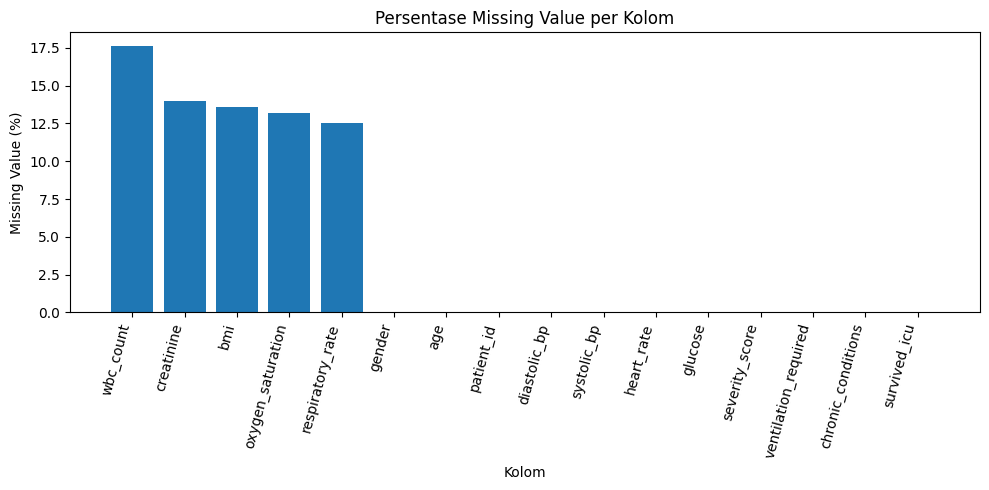

Jumlah baris yang memiliki minimal satu missing value: 808


In [10]:
missing_pct = df.isna().mean().mul(100).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(missing_pct.index, missing_pct.values)
plt.title("Persentase Missing Value per Kolom")
plt.xlabel("Kolom")
plt.ylabel("Missing Value (%)")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()

print("Jumlah baris yang memiliki minimal satu missing value:",
      df.isna().any(axis=1).sum())

### 3.2 Duplicate

#### 3.2.1 Pemeriksaan Duplicate

Pemeriksaan duplicate dilakukan dengan tiga cara, yaitu berdasarkan seluruh kolom, berdasarkan `patient_id`, dan berdasarkan seluruh kolom selain `patient_id`.

Pemeriksaan berdasarkan `patient_id` digunakan untuk mengetahui apakah terdapat identitas pasien yang berulang. Sementara itu, pemeriksaan tanpa `patient_id` digunakan untuk mencari baris dengan kombinasi fitur dan target yang sama meskipun identitasnya berbeda.

Hasil pemeriksaan menjadi dasar untuk meninjau kemungkinan adanya data duplikat yang perlu ditangani.

In [11]:
print("Duplicate seluruh kolom:", df.duplicated().sum())
print("Duplicate patient_id:", df["patient_id"].duplicated().sum())

tanpa_id = df.drop(columns=["patient_id"])
print("Baris yang terlibat duplicate berdasarkan fitur + target:",
      tanpa_id.duplicated(keep=False).sum())

Duplicate seluruh kolom: 0
Duplicate patient_id: 0
Baris yang terlibat duplicate berdasarkan fitur + target: 116


#### 3.2.2 Menampilkan Baris yang Terlibat Duplicate

Pada tahap ini baris yang terlibat dalam duplicate berdasarkan fitur dan target ditampilkan menggunakan hasil pemeriksaan sebelumnya.

Parameter `keep=False` menandai seluruh baris yang memiliki pasangan duplikat, bukan hanya kemunculan setelah baris pertama. Hasilnya diurutkan agar baris dengan kombinasi nilai yang sama lebih mudah dibandingkan.

In [12]:
tanpa_id = df.drop(columns=["patient_id"])
duplicate_mask = tanpa_id.duplicated(keep=False)
data_duplicate = (df.loc[duplicate_mask].sort_values(by=list(tanpa_id.columns)))

display(data_duplicate)

,patient_id,age,gender,bmi,heart_rate,systolic_bp,diastolic_bp,respiratory_rate,oxygen_saturation,glucose,creatinine,wbc_count,severity_score,ventilation_required,chronic_conditions,survived_icu
369,ICU_DUP_0042,18,1,35.3,97.5,149.0,34.1,24.4,92.9,155.6,0.30,3.49,21,0,5,1
2820,ICU_05907,18,1,35.3,97.5,149.0,34.1,24.4,92.9,155.6,0.30,3.49,21,0,5,1
3378,ICU_00013,27,1,28.7,132.0,115.8,70.2,14.5,97.0,202.1,2.27,16.12,22,0,0,1
4547,ICU_DUP_0030,27,1,28.7,132.0,115.8,70.2,14.5,97.0,202.1,2.27,16.12,22,0,0,1
1965,ICU_02280,30,0,27.2,109.4,106.5,96.2,10.3,92.4,148.5,1.10,17.42,18,0,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019,ICU_DUP_0029,95,1,20.7,71.0,66.4,63.8,13.4,91.8,204.5,3.33,22.91,22,0,5,0
3349,ICU_DUP_0008,95,1,28.6,49.6,122.6,95.1,18.0,90.4,144.1,1.77,22.77,9,1,2,1
4168,ICU_03982,95,1,28.6,49.6,122.6,95.1,18.0,90.4,144.1,1.77,22.77,9,1,2,1
766,ICU_DUP_0015,95,1,32.9,64.5,195.2,69.6,19.6,85.7,250.1,0.96,43.03,15,1,1,0


#### 3.2.3 Pemeriksaan Pola Identitas Pasien

Kolom `patient_id` diperiksa berdasarkan pola penulisan identitas yang diharapkan.

Pola `ICU_` diikuti lima digit diperiksa sebagai ID normal, sedangkan pola `ICU_DUP_` diikuti empat digit diperiksa sebagai ID dengan penanda DUP. Nilai yang tidak memenuhi kedua pola tersebut ditandai sebagai ID tidak dikenal.

Pemeriksaan ini bertujuan untuk menemukan identitas dengan format yang berbeda dari pola yang telah ditentukan. Hasilnya perlu ditinjau bersama informasi dataset sebelum menentukan tindakan cleaning.

In [13]:
id_normal = df["patient_id"].str.match(r"^ICU_\d{5}$")
id_duplicate_style = df["patient_id"].str.match(r"^ICU_DUP_\d{4}$")
id_invalid = ~(id_normal | id_duplicate_style)
print("ID normal        :", id_normal.sum())
print("ID pola DUP      :", id_duplicate_style.sum())
print("ID tidak dikenal :", id_invalid.sum())

ID normal        : 4500
ID pola DUP      : 80
ID tidak dikenal : 0


#### 3.2.4 Meninjau ID dengan Penanda DUP

Pada tahap ini ditampilkan maksimal 15 baris pertama yang memiliki `patient_id` dengan awalan `ICU_DUP_`.

Peninjauan ini membantu melihat contoh data yang memiliki penanda DUP dan memeriksa apakah penanda tersebut berkaitan dengan baris yang terduplikasi. Penanda pada ID saja belum membuktikan bahwa seluruh isi baris merupakan duplikat, sehingga tetap diperlukan perbandingan fitur dan target.

In [14]:
display(df[df["patient_id"].str.startswith("ICU_DUP_")].head(15))

,patient_id,age,gender,bmi,heart_rate,systolic_bp,diastolic_bp,respiratory_rate,oxygen_saturation,glucose,creatinine,wbc_count,severity_score,ventilation_required,chronic_conditions,survived_icu
34,ICU_DUP_0018,43,1,21.4,87.3,139.4,98.1,11.2,85.5,262.5,0.36,1.08,10,0,1,1
54,ICU_DUP_0061,53,1,32.0,94.1,97.7,50.0,27.1,96.2,69.2,3.04,1.00,23,0,0,1
82,ICU_DUP_0043,58,1,23.2,116.6,129.2,82.1,8.3,90.9,92.5,0.31,11.28,23,1,1,0
369,ICU_DUP_0042,18,1,35.3,97.5,149.0,34.1,24.4,92.9,155.6,0.30,3.49,21,0,5,1
396,ICU_DUP_0028,71,0,26.4,95.8,155.4,89.7,18.4,89.8,122.7,0.32,4.09,8,0,3,0
410,ICU_DUP_0047,79,0,22.7,105.1,112.2,87.7,12.7,100.0,222.2,0.33,10.89,7,0,0,0
416,ICU_DUP_0074,80,1,28.4,102.1,189.0,130.0,21.7,95.0,96.2,0.30,6.14,14,0,1,1
418,ICU_DUP_0020,51,0,NaN,53.2,106.6,63.6,NaN,NaN,236.5,NaN,NaN,0,0,3,0
463,ICU_DUP_0079,57,0,NaN,78.8,91.4,48.0,24.7,95.5,75.9,NaN,NaN,16,0,3,1
474,ICU_DUP_0013,39,0,21.0,104.0,105.8,67.2,23.0,99.3,119.6,0.30,1.00,23,0,0,1


In [15]:
# df_cek = df.copy()

# # Tandai ID DUP
# mask_dup = df_cek["patient_id"].str.startswith("ICU_DUP_")

# # angka di belakang ID
# df_cek["nomor_id"] = (
#     df_cek["patient_id"]
#     .str.extract(r"(\d+)$")[0]
#     .astype(int)
# )

# id_dup = df_cek.loc[mask_dup].copy()
# id_normal = df_cek.loc[~mask_dup].copy()

# # Cari nomor ICU_DUP_ yang juga ada pada ID normal
# pasangan_id = (
#     id_dup[["patient_id", "nomor_id"]]
#     .merge(
#         id_normal[["patient_id", "nomor_id"]],
#         on="nomor_id",
#         how="inner",
#         suffixes=("_dup", "_normal")
#     )
# )

# print("Jumlah ICU_DUP_ pada data mentah:", len(id_dup))
# print("Jumlah yang nomor belakangnya sama dengan ID normal:", len(pasangan_id))

# display(pasangan_id)

In [16]:
# df_id = df[["patient_id"]].copy()

# df_id["nomor"] = (
#     df_id["patient_id"]
#     .str.extract(r"(\d+)$")[0]
#     .astype(int)
# )

# df_id["jenis_id"] = (
#     df_id["patient_id"]
#     .str.startswith("ICU_DUP_")
#     .map({
#         True: "DUP",
#         False: "NORMAL"
#     })
# )

# df_id = (
#     df_id
#     .sort_values(
#         by=["nomor", "jenis_id"]
#     )
#     .reset_index(drop=True)
# )

# pd.set_option("display.max_rows", None)
# pd.set_option("display.max_columns", None)

# display(df_id.head(40))

In [17]:
# dup_id = df[
#     df["patient_id"].str.startswith("ICU_DUP_")
# ].copy()

# dup_id["nomor"] = (
#     dup_id["patient_id"]
#     .str.extract(r"(\d+)$")[0]
#     .astype(int)
# )

# dup_id = dup_id.sort_values("nomor")

# print("Jumlah ICU_DUP_:", len(dup_id))
# print("Nomor minimum:", dup_id["nomor"].min())
# print("Nomor maksimum:", dup_id["nomor"].max())
# pd.set_option("display.max_rows", None)
# pd.set_option("display.max_columns", None)
# display(dup_id[["patient_id", "nomor"]])

### 3.3 Outlier

Pemriksaan Outlier digunakan untuk melihat sebaran data dan nilai yang jauh dari kelompok utama. Namun, perluu diperhatikan sebelumnya, outlier tidak selalu salah. Oleh karena itu kita juga memakai pemeriksaan logis/domain.

#### 3.3.1 Menentukan Fitur Numerik untuk Pemeriksaan Outlier

Daftar fitur numerik kontinu ditentukan terlebih dahulu agar pemeriksaan outlier hanya dilakukan pada variabel yang sesuai, seperti usia, BMI, denyut jantung, tekanan darah, frekuensi napas, saturasi oksigen, glukosa, kreatinin, dan jumlah sel darah putih.

In [18]:
continuous_features = [
    "age",
    "bmi",
    "heart_rate",
    "systolic_bp",
    "diastolic_bp",
    "respiratory_rate",
    "oxygen_saturation",
    "glucose",
    "creatinine",
    "wbc_count"
]

#### 3.3.2 Menghitung Kandidat Outlier dengan Metode IQR

Pemeriksaan kandidat outlier dilakukan menggunakan metode Interquartile Range (IQR).

Kuartil pertama (Q1) dan kuartil ketiga (Q3) digunakan untuk menghitung IQR, yaitu selisih antara Q3 dan Q1. Batas bawah dihitung dengan Q1 − 1,5 × IQR, sedangkan batas atas dihitung dengan Q3 + 1,5 × IQR.

Nilai di luar batas tersebut ditandai sebagai kandidat outlier. Jumlah dan persentasenya dirangkum untuk setiap fitur. Kandidat outlier tidak otomatis dianggap sebagai kesalahan dan perlu ditinjau lebih lanjut.

In [19]:
hasil_outlier = []

for kolom in continuous_features:

    Q1 = df[kolom].quantile(0.25)
    Q3 = df[kolom].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier = (
        (df[kolom] < lower_bound) |
        (df[kolom] > upper_bound)
    )

    hasil_outlier.append({
        "fitur": kolom,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "jumlah_outlier": outlier.sum(),
        "persentase": round(outlier.mean() * 100, 2)
    })

outlier_table = pd.DataFrame(hasil_outlier)

display(outlier_table)

,fitur,lower_bound,upper_bound,jumlah_outlier,persentase
0,age,15.50000,107.50000,0,0.00
1,bmi,6.45000,46.85000,47,1.03
2,heart_rate,29.20000,148.40000,106,2.31
3,systolic_bp,38.30000,199.10000,101,2.21
4,diastolic_bp,23.80000,119.80000,16,0.35
5,respiratory_rate,1.60000,34.40000,8,0.17
6,oxygen_saturation,81.65000,108.45000,15,0.33
7,glucose,-26.30000,309.90000,95,2.07
8,creatinine,-1.72500,3.83500,198,4.32
9,wbc_count,-14.32375,31.44625,163,3.56


### 3.4 Pemeriksaan Nilai Tidak Logis

Beberapa aturan sederhana digunakan untuk mencari noise, misalnya nilai fisiologis negatif, saturasi di atas 100%, atau tekanan sistolik lebih kecil daripada diastolik.

#### 3.4.1 Pemeriksaan Aturan Logis

Pada tahap ini dilakukan pemeriksaan terhadap nilai yang berpotensi tidak masuk akal berdasarkan aturan yang telah ditentukan, misalnya usia negatif, BMI tidak positif, saturasi oksigen di luar rentang 0–100, serta tekanan sistolik yang lebih rendah daripada tekanan diastolik.

Setiap kondisi dihitung jumlah kemunculannya. Hasil ini digunakan untuk mengidentifikasi nilai yang memerlukan peninjauan lebih lanjut sebelum proses cleaning.

In [20]:
logical_check = {
    "age < 0": (df["age"] < 0).sum(),
    "bmi <= 0": (df["bmi"] <= 0).sum(),
    "heart_rate <= 0": (df["heart_rate"] <= 0).sum(),
    "systolic_bp <= 0": (df["systolic_bp"] <= 0).sum(),
    "diastolic_bp <= 0": (df["diastolic_bp"] <= 0).sum(),
    "systolic < diastolic": (df["systolic_bp"] < df["diastolic_bp"]).sum(),
    "respiratory_rate <= 0": (df["respiratory_rate"] <= 0).sum(),
    "oxygen_saturation di luar 0-100":
        ((df["oxygen_saturation"] < 0) | (df["oxygen_saturation"] > 100)).sum(),
    "glucose <= 0": (df["glucose"] <= 0).sum(),
    "creatinine < 0": (df["creatinine"] < 0).sum(),
    "wbc_count < 0": (df["wbc_count"] < 0).sum()
}

display(pd.Series(logical_check, name="jumlah"))

age < 0                              0
bmi <= 0                             0
heart_rate <= 0                      0
systolic_bp <= 0                     0
diastolic_bp <= 0                    0
systolic < diastolic               344
respiratory_rate <= 0                0
oxygen_saturation di luar 0-100      0
glucose <= 0                         0
creatinine < 0                       0
wbc_count < 0                        0
Name: jumlah, dtype: int64

#### 3.4.2 Menampilkan Ketidakkonsistenan Tekanan Darah

Pemeriksaan ini mengambil baris yang memiliki nilai `systolic_bp` lebih kecil daripada `diastolic_bp`.

Kolom identitas pasien dan kedua nilai tekanan darah ditampilkan agar kasus yang terdeteksi dapat diperiksa secara langsung. Hasil ini menjadi dasar untuk meninjau ketidakkonsistenan sebelum dilakukan perbaikan.

In [21]:
bp_anomali = df[df["systolic_bp"] < df["diastolic_bp"]]
display( bp_anomali[["patient_id","systolic_bp","diastolic_bp"]].head(20))

,patient_id,systolic_bp,diastolic_bp
12,ICU_03249,95.9,115.5
13,ICU_03997,68.7,80.4
65,ICU_04279,60.1,72.7
71,ICU_04038,83.3,99.0
97,ICU_02256,93.1,99.7
104,ICU_00764,81.0,89.3
118,ICU_05584,69.6,73.8
119,ICU_02566,60.0,88.8
133,ICU_00587,76.6,103.4
142,ICU_00290,76.7,94.3


### 3.5 Distribusi Data — Histogram

Histogram membantu melihat bentuk distribusi setiap fitur, misalnya apakah data terkonsentrasi pada rentang tertentu atau memiliki ekor panjang.

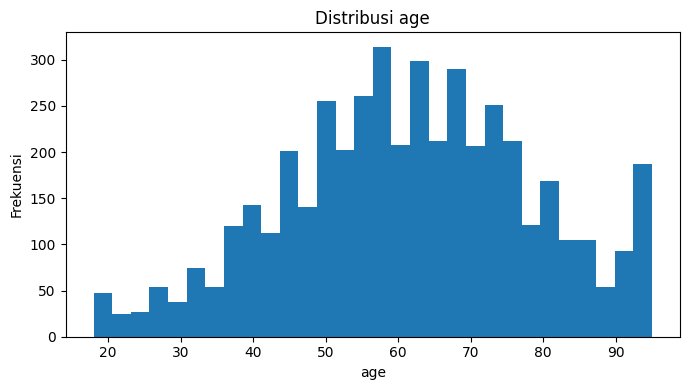

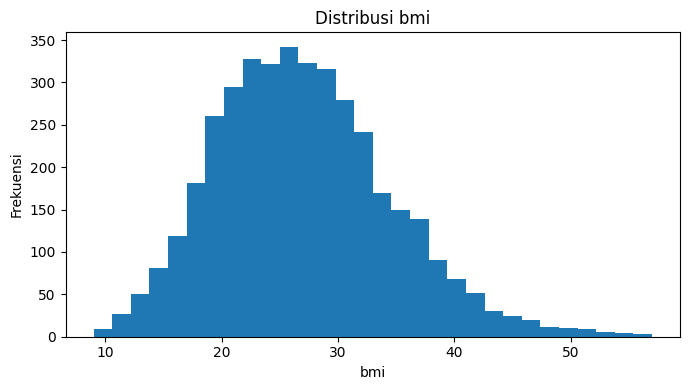

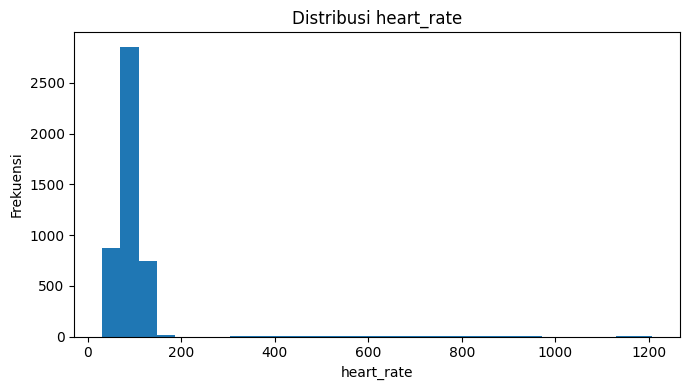

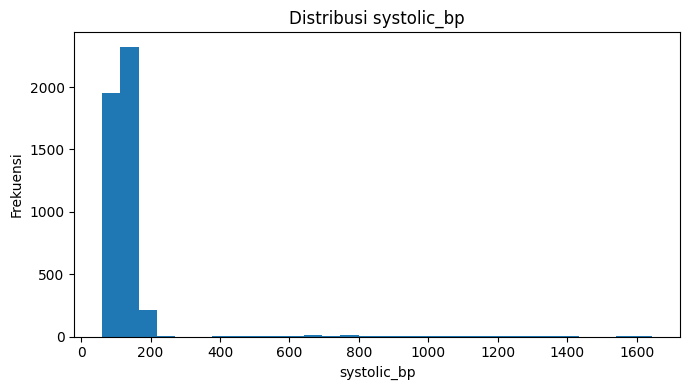

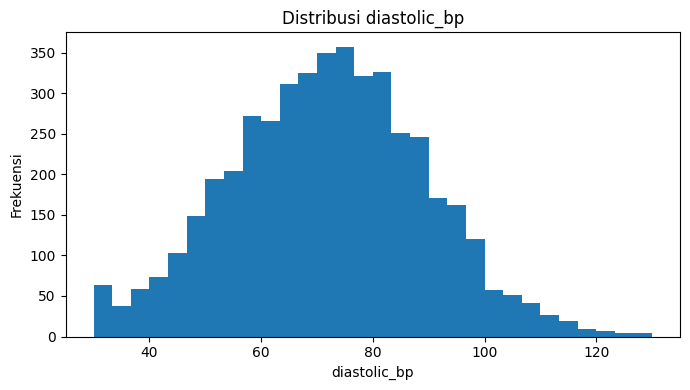

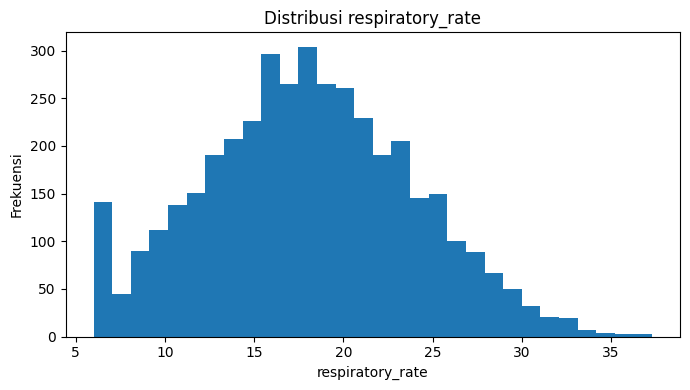

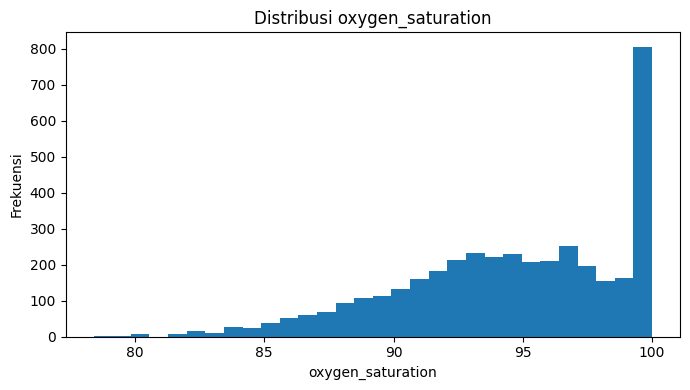

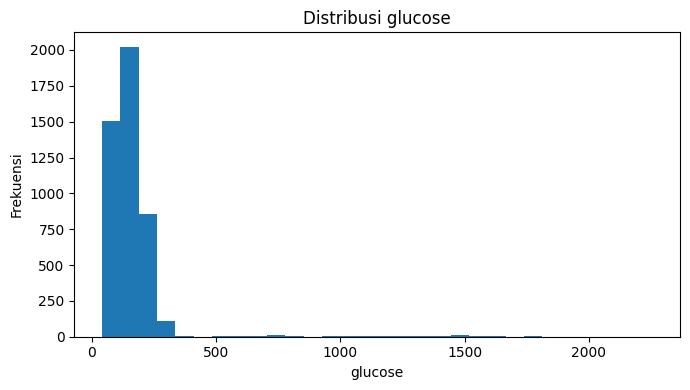

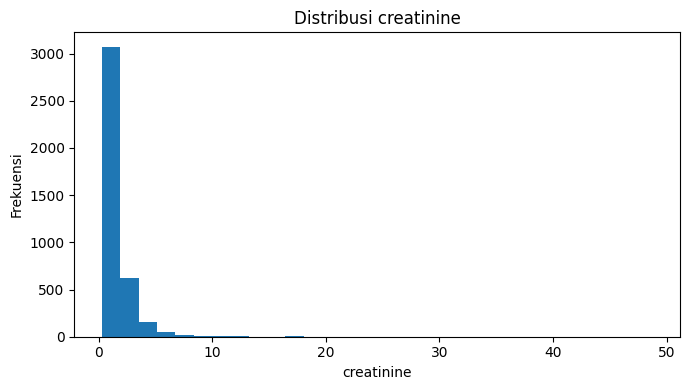

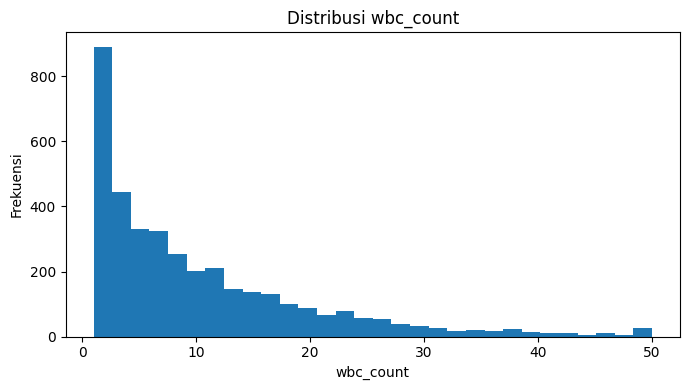

In [22]:
for col in continuous_features:
    plt.figure(figsize=(7, 4))
    plt.hist(df[col].dropna(), bins=30)
    plt.title(f"Distribusi {col}")
    plt.xlabel(col)
    plt.ylabel("Frekuensi")
    plt.tight_layout()
    plt.show()

**Interpretasi**

- Pada `heart_rate`, hampir seluruh data menumpuk di kisaran 50–150 (puncak sekitar 80–100), sedangkan sebagian kecil nilai tersebar sampai sekitar 1.200 dan membentuk **ekor sangat panjang ke kanan**. Rentang sumbu x jadi sangat lebar sehingga bagian utama data tampak menyempit.
- Pola serupa diperkirakan pada `systolic_bp` dan `glucose` karena statistik dan boxplot-nya menunjukkan nilai ekstrem yang sama. `creatinine` dan `wbc_count` juga cenderung **miring ke kanan**.
- `age`, `diastolic_bp`, `respiratory_rate`, dan `oxygen_saturation` sebarannya lebih terkonsentrasi dan tidak terdistorsi nilai ekstrem.
- Distribusi yang miring dan nilai ekstrem ini memperkuat alasan melakukan **cleaning** dan **standardisasi** sebelum modeling.

## 4. Data Cleaning

Berdasarkan pemeriksaan sebelumnya, cleaning dilakukan dengan langkah sederhana:

1. Menghapus duplicate tambahan.
2. Menghapus baris yang jelas mengalami corrupted extreme values.
3. Memperbaiki kasus *systolic_bp < diastolic_bp* dengan menukar kedua nilai.
4. Missing value **tidak langsung dibuang**, tetapi akan ditangani dengan **median imputation** saat preprocessing model.

Langkah 1 cleaning: menghapus duplikat berdasarkan **semua kolom selain `patient_id`** (`non_id_cols`).

1. Dibuat kolom bantu `_is_dup_id` (1 jika ID berawalan `ICU_DUP_`, 0 jika tidak).
2. Data diurutkan menurut kolom itu, sehingga baris **ID normal berada di atas** baris `DUP`.
3. `duplicated(keep="first")` mempertahankan baris pertama dan menandai sisanya sebagai duplikat. Akibatnya, baris dengan ID normal dipertahankan dan baris `DUP` yang dibuang.
4. Kolom bantu dihapus dan index direset.

`df_raw` menyimpan salinan data asli sebagai pembanding, dan `df_clean` adalah salinan yang dibersihkan.

In [23]:
df_raw = df.copy()
df_clean = df.copy()

# 1. Hapus duplicate berdasarkan seluruh kolom selain patient_id.
non_id_cols = [c for c in df_clean.columns if c != "patient_id"]
df_clean["_is_dup_id"] = (df_clean["patient_id"].str.startswith("ICU_DUP_").astype(int))
df_clean = (df_clean.sort_values("_is_dup_id").reset_index(drop=True))

duplicate_mask = df_clean.duplicated(
    subset=non_id_cols,
    keep="first"
)
n_removed_duplicate = duplicate_mask.sum()
df_clean = df_clean.loc[~duplicate_mask].copy()
df_clean = (df_clean.drop(columns="_is_dup_id").reset_index(drop=True))

print("Duplicate ID_DUP yang dibuang:", n_removed_duplicate)
print("Ukuran setelah duplicate dibuang:",df_clean.shape)

Duplicate ID_DUP yang dibuang: 58
Ukuran setelah duplicate dibuang: (4522, 16)


Cell ini memeriksa apakah masih ada `patient_id` berpola `ICU_DUP_` di `df_clean` setelah duplikat dibuang, dan menampilkan daftarnya.

In [24]:
dup_id_mask = (df_clean["patient_id"].str.startswith("ICU_DUP_"))
print("Jumlah ID ICU_DUP sisah:", dup_id_mask.sum()) 
display(df_clean.loc[dup_id_mask,["patient_id"]])

Jumlah ID ICU_DUP sisah: 22


,patient_id
4500,ICU_DUP_0043
4501,ICU_DUP_0020
4502,ICU_DUP_0079
4503,ICU_DUP_0059
4504,ICU_DUP_0036
4505,ICU_DUP_0001
4506,ICU_DUP_0072
4507,ICU_DUP_0019
4508,ICU_DUP_0000
4509,ICU_DUP_0003


In [25]:
# # Pisahkan ID DUP dan ID normal
# id_dup = df_clean[df_clean["patient_id"].str.startswith("ICU_DUP_")].copy()

# id_normal = df_clean[~df_clean["patient_id"].str.startswith("ICU_DUP_")].copy()

# # Ambil angka di belakang ID
# id_dup["nomor"] = (id_dup["patient_id"].str.extract(r"(\d+)$")[0].astype(int))

# id_normal["nomor"] = (id_normal["patient_id"].str.extract(r"(\d+)$")[0].astype(int))

# # Cek apakah nomor ICU_DUP_ sudah ada di ID normal
# cek_sama = id_dup["nomor"].isin(id_normal["nomor"])

# print("Jumlah nomor DUP yang sudah ada di ID normal:",cek_sama.sum())

In [26]:
# pasangan_id = (
#     id_dup[["patient_id", "nomor"]]
#     .merge(
#         id_normal[["patient_id", "nomor"]],
#         on="nomor",
#         how="inner",
#         suffixes=("_dup", "_normal")
#     )
# )

# display(pasangan_id)

### Pemeriksaan Nilai Ekstrem pada Denyut Jantung dan Tekanan Sistolik
Sebelum menghapus nilai ekstrem, cell ini memeriksa **apakah ambang yang dipilih benar-benar memisahkan** data wajar dari data ekstrem. Untuk `heart_rate` (ambang 250) dan `systolic_bp` (ambang 300), dicetak:

- nilai **tertinggi** di bawah/sama dengan ambang, dan
- nilai **terendah** di atas ambang.

Jika ada celah besar antara keduanya, ambang tersebut punya dasar yang kuat.

In [27]:
# pemeriksaan nilai extreme corrupt pada heart_rate dan systolic_bp
cek_extreme_corrupt = { "heart_rate": 250,"systolic_bp": 300}
for col, batas in cek_extreme_corrupt.items():
    print(f"{col} tertinggi <= {batas}:",df_clean.loc[df_clean[col] <= batas,col].max())
    print(f"{col} terendah > {batas}:",df_clean.loc[df_clean[col] > batas,col].min())
    print()

heart_rate tertinggi <= 250: 169.2
heart_rate terendah > 250: 314.5521893515285

systolic_bp tertinggi <= 300: 220.0
systolic_bp terendah > 300: 381.7834844177826



### Mengidentifikasi Baris dengan Dua Nilai Ekstrem

Pada tahap ini dicari baris yang secara bersamaan memiliki `heart_rate > 250` dan `systolic_bp > 300`.

Operator `&` memastikan bahwa kedua kondisi harus terpenuhi. Baris yang memenuhi kondisi disimpan sementara untuk diperiksa jumlahnya dan ditinjau lebih lanjut sebelum penghapusan.

In [28]:
extreme_both = (
    (df_clean["heart_rate"] > 250)
    &
    (df_clean["systolic_bp"] > 300)
)
df_92_extreme =(  df_clean.loc[extreme_both].copy())
print("Jumlah pasien ekstrem:",len(df_92_extreme))

Jumlah pasien ekstrem: 92


Untuk memastikan 92 pasien ini memang **data rusak** (bukan sekadar pasien kritis), cell ini membandingkan `glucose` dan `creatinine` pada dua kelompok dengan `describe()`:

1. kelompok **HR + SBP ekstrem**, dan
2. kelompok **di luar** itu.

Jika kelompok ekstrem juga memiliki nilai tidak wajar pada kolom lain, itu bukti tambahan bahwa baris tersebut rusak secara keseluruhan.

In [29]:
extreme_both = ((df_clean["heart_rate"] > 250)&(df_clean["systolic_bp"] > 300))
fitur_cek = ["glucose","creatinine"]
print("KELOMPOK HR + SBP EKSTREM")
display(df_clean.loc[extreme_both,fitur_cek].describe(percentiles=[0.25,0.50,0.75,0.90,0.95,0.99]).T)
print("DI LUAR KELOMPOK HR + SBP EKSTREM")
display(df_clean.loc[~extreme_both,fitur_cek].describe(percentiles=[0.25,0.50,0.75,0.90,0.95,0.99]).T)

KELOMPOK HR + SBP EKSTREM


,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
glucose,92.0,1073.548502,453.166076,208.986544,734.316771,1070.096463,1427.126426,1598.785984,1761.433983,2132.079958,2256.210085
creatinine,77.0,7.969650,7.797991,1.512089,2.962469,5.233237,8.701402,17.111897,22.721197,34.413958,48.737770


DI LUAR KELOMPOK HR + SBP EKSTREM


,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
glucose,4430.0,140.704831,58.375889,40.0,98.90,139.35,181.00,216.400,241.81,279.1420,364.70
creatinine,3804.0,1.238680,1.145799,0.3,0.36,0.87,1.67,2.707,3.51,5.5288,10.71


#### Menghapus Baris yang Memenuhi Aturan Corrupted Extreme

Berdasarkan aturan yang digunakan dalam notebook, baris yang memiliki `heart_rate > 250` sekaligus `systolic_bp > 300` ditandai sebagai corrupted extreme.

Jumlah baris yang memenuhi kondisi dihitung, kemudian baris tersebut dikeluarkan dari `df_clean`. Jumlah data yang dihapus dicatat untuk membantu melacak perubahan dataset selama proses cleaning.

Aturan ini merupakan keputusan cleaning yang perlu dijelaskan dan dipertanggungjawabkan berdasarkan hasil pemeriksaan data.

In [30]:
# 2. Hapus corrupted extreme rows.
# Berdasarkan pemeriksaan nilai extreme corrupt:
# heart_rate > 250 dan systolic_bp > 300 dianggap corrupted extreme.

extreme_corrupt = (
    (df_clean["heart_rate"] > 250) &
    (df_clean["systolic_bp"] > 300)
)

n_removed_extreme = extreme_corrupt.sum()
df_clean = df_clean.loc[~extreme_corrupt].copy()
print("HR ekstrem :", extreme_corrupt.sum())
print("SBP ekstrem:", extreme_corrupt.sum())
print("Keduanya:",(extreme_corrupt & extreme_corrupt).sum())
print("Corrupted extreme rows pada keduanyayang dibuang:", n_removed_extreme)

HR ekstrem : 92
SBP ekstrem: 92
Keduanya: 92
Corrupted extreme rows pada keduanyayang dibuang: 92


In [31]:
# fitur_cleaning = ["heart_rate","systolic_bp","glucose", "creatinine"]

# for col in fitur_cleaning:
#     plt.figure(figsize=(7, 4))
#     plt.hist(df_clean[col].dropna(),bins=30)
#     plt.title(f"Distribusi {col} Setelah Cleaning")
#     plt.xlabel(col)
#     plt.ylabel("Frekuensi")
#     plt.tight_layout()
#     plt.show()

#### Mengidentifikasi Ketidakkonsistenan Tekanan Darah

Setelah penghapusan baris ekstrem, data diperiksa kembali untuk menemukan kondisi `systolic_bp < diastolic_bp`.

Masker kondisi disimpan dalam `bp_inconsistent`, kemudian jumlah baris yang memenuhi kondisi tersebut dihitung. Masker ini digunakan pada langkah berikutnya untuk memperbaiki baris yang teridentifikasi.

In [32]:
# 3. cek tekanan darah yang tidak konsisten.
bp_inconsistent = df_clean["systolic_bp"] < df_clean["diastolic_bp"]

n_bp_corrected = bp_inconsistent.sum()
print("Jumlah systolic_bp < diastolic_bp:",bp_inconsistent.sum())

Jumlah systolic_bp < diastolic_bp: 343


#### Memperbaiki Urutan Tekanan Darah

Untuk baris yang memenuhi kondisi `systolic_bp < diastolic_bp`, kedua nilai tekanan darah ditukar posisinya.

Nilai sistolik lama disimpan sementara agar tidak hilang ketika kolom diperbarui. Setelah pertukaran dilakukan, jumlah baris yang diperbaiki dan jumlah ketidakkonsistenan yang masih tersisa diperiksa kembali.

In [33]:
# 3. perbaikan tekanan darah yang tidak konsisten yang ditemukan.
systolic_lama = df_clean.loc[bp_inconsistent, "systolic_bp"].copy()
df_clean.loc[bp_inconsistent, "systolic_bp"] = ( df_clean.loc[bp_inconsistent,"diastolic_bp"].values)
df_clean.loc[bp_inconsistent, "diastolic_bp"] = systolic_lama.values

print("Baris dengan tekanan darah yang diperbaiki:", n_bp_corrected)
print("Systolic < diastolic setelah cleaning:",(df_clean["systolic_bp"] < df_clean["diastolic_bp"]).sum())

Baris dengan tekanan darah yang diperbaiki: 343
Systolic < diastolic setelah cleaning: 0


Cell ini menampilkan kembali 20 baris yang tadi diperbaiki (`df_clean.loc[bp_inconsistent, ...]`) untuk membandingkan nilainya **sebelum dan sesudah** penukaran.

In [34]:
# Cek tabel setelah perbaikan
display(df_clean.loc[bp_inconsistent,["patient_id","systolic_bp","diastolic_bp"]].head(20))

,patient_id,systolic_bp,diastolic_bp
12,ICU_03249,115.5,95.9
13,ICU_03997,80.4,68.7
65,ICU_04279,72.7,60.1
71,ICU_04038,99.0,83.3
82,ICU_05089,75.9,68.5
97,ICU_02256,99.7,93.1
104,ICU_00764,89.3,81.0
118,ICU_05584,73.8,69.6
119,ICU_02566,88.8,60.0
133,ICU_00587,103.4,76.6



`cleaning_log` merangkum semua langkah cleaning dalam satu tabel: jumlah baris awal, baris yang dibuang, baris yang diperbaiki, dan jumlah baris akhir. Berguna sebagai bukti transparansi proses pembersihan.

In [35]:
cleaning_log = pd.DataFrame({
    "proses": [
        "Data awal",
        "Hapus duplicate ID_DUP",
        "Hapus corrupted extreme",
        "Perbaiki systolic < diastolic",
        "Data akhir"
    ],
    "jumlah": [
        len(df_raw),
        n_removed_duplicate,
        n_removed_extreme,
        n_bp_corrected,
        len(df_clean)
    ],
    "jenis": [
        "jumlah baris",
        "baris dibuang",
        "baris dibuang",
        "baris diperbaiki",
        "jumlah baris"
    ]
})

display(cleaning_log)
print("Ukuran awal :", df_raw.shape)
print("Ukuran akhir:", df_clean.shape)

,proses,jumlah,jenis
0,Data awal,4580,jumlah baris
1,Hapus duplicate ID_DUP,58,baris dibuang
2,Hapus corrupted extreme,92,baris dibuang
3,Perbaiki systolic < diastolic,343,baris diperbaiki
4,Data akhir,4430,jumlah baris


Ukuran awal : (4580, 16)
Ukuran akhir: (4430, 16)


### 4.1 Pengecekan ulang Setelah Cleaning

### Validasi Dataset Setelah Cleaning

Validasi dilakukan untuk memastikan beberapa aturan cleaning telah terpenuhi. Pemeriksaan mencakup keunikan `patient_id`, tidak adanya duplicate berdasarkan fitur dan target, tidak adanya baris yang memenuhi aturan corrupted extreme, serta konsistensi urutan tekanan darah.

Selain itu, nilai target `survived_icu` dan variabel `ventilation_required` diperiksa agar hanya berisi kelas 0 atau 1.

Fungsi `assert` akan menghentikan eksekusi apabila suatu kondisi tidak terpenuhi. Jika seluruh pemeriksaan lolos, pesan keberhasilan akan ditampilkan.


In [36]:
assert df_clean["patient_id"].is_unique
assert not df_clean.duplicated(subset=non_id_cols,keep=False).any()
assert not ((df_clean["heart_rate"] > 250)&(df_clean["systolic_bp"] > 300)).any()
assert (df_clean["systolic_bp"]>=df_clean["diastolic_bp"]).all()
assert set(df_clean["survived_icu"].unique()).issubset({0, 1})
assert set(df_clean["ventilation_required"].unique()).issubset({0, 1})
print("Semua pemeriksaan cleaning berhasil.")

Semua pemeriksaan cleaning berhasil.


### 4.2 Heatmap Korelasi

Heatmap menampilkan **korelasi Spearman** antar semua variabel numerik setelah cleaning. Spearman dipilih karena berbasis peringkat, sehingga lebih tahan terhadap outlier dan tidak mengharuskan hubungan linear sempurna.

Skala warna: kuning mendekati **+1** (korelasi positif kuat), ungu tua mendekati **−1** (korelasi negatif kuat), dan hijau-kebiruan di tengah mendekati **0** (hampir tidak ada hubungan).

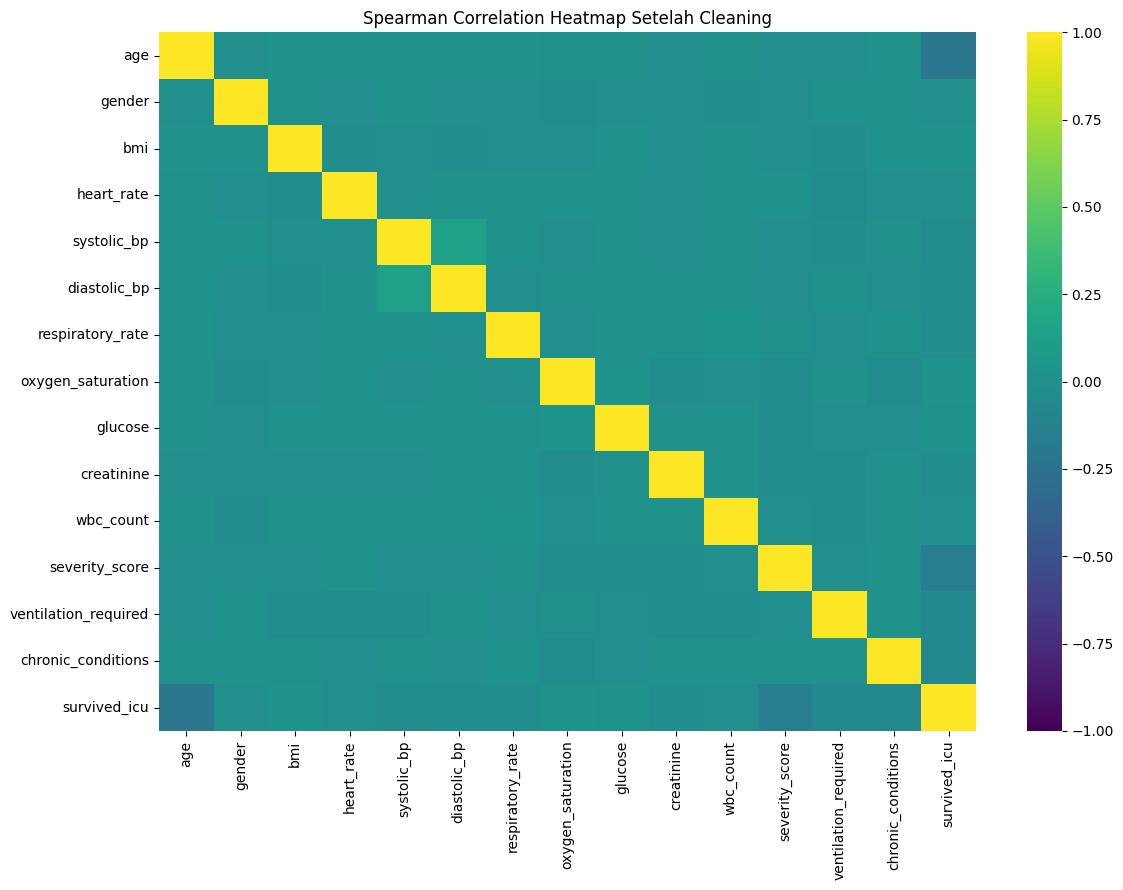

In [37]:
numeric_cols = df_clean.select_dtypes(include="number").columns
corr_spearman = df_clean[numeric_cols].corr(method="spearman")

plt.figure(figsize=(12, 9))
sns.heatmap(
    corr_spearman,
    cmap="viridis",
    vmin=-1,
    vmax=1,
    annot=False
)
plt.title("Spearman Correlation Heatmap Setelah Cleaning")
plt.tight_layout()
plt.show()

Cell ini mengambil kolom `survived_icu` dari matriks korelasi, membuang korelasi target dengan dirinya sendiri, lalu mengurutkannya berdasarkan **nilai absolut** (`key=abs`) dari yang terkuat ke terlemah. Tujuannya melihat fitur mana yang paling berhubungan dengan kelangsungan hidup sebelum modeling.

In [38]:
corr_target = (
    corr_spearman["survived_icu"]
    .drop("survived_icu")
    .sort_values(key=abs, ascending=False)
)

display(
    corr_target.to_frame("Spearman_Correlation").round(3)
)

,Spearman_Correlation
age,-0.206
severity_score,-0.153
ventilation_required,-0.062
chronic_conditions,-0.057
systolic_bp,-0.038
oxygen_saturation,0.031
diastolic_bp,-0.031
bmi,0.028
creatinine,-0.028
respiratory_rate,-0.018


## 5. Supervised Learning

**Supervised learning** adalah pembelajaran mesin menggunakan data yang sudah mempunyai **label/target**.

Pada kasus ini:

- **Input (X):** karakteristik pasien ICU.
- **Target (y):** **survived_icu**.
- Model belajar hubungan X → y dari data training.
- Setelah belajar, model diuji pada data testing yang tidak digunakan saat training.

Karena target hanya memiliki dua kelas (0 dan 1), kita menggunakan **klasifikasi biner**.

### 5.1 Menentukan X dan y + Train-Test Split

Data dibagi menjadi training dan testing sebelum preprocessing yang mempelajari parameter dari data. Ini dilakukan untuk menghindari **data leakage**.


In [39]:
X = df_clean.drop(columns=["patient_id", "survived_icu"])
y = df_clean["survived_icu"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Data training:", X_train.shape)
print("Data testing :", X_test.shape)

print("\nDistribusi target training:")
display(y_train.value_counts(normalize=True).mul(100).round(2))

print("\nDistribusi target testing:")
display(y_test.value_counts(normalize=True).mul(100).round(2))

Data training: (3544, 14)
Data testing : (886, 14)

Distribusi target training:


survived_icu
1    64.53
0    35.47
Name: proportion, dtype: float64


Distribusi target testing:


survived_icu
1    64.56
0    35.44
Name: proportion, dtype: float64

### 5.2 Preprocessing untuk Logistic Regression

Langkah preprocessing yang dipakai sengaja sederhana:

1. **Median imputation** → mengisi missing value numerik dengan nilai tengah.
2. **StandardScaler** → menyamakan skala fitur agar fitur dengan rentang besar tidak mendominasi proses optimasi.
3. **Logistic Regression** → model klasifikasi biner.

Semua langkah dimasukkan ke dalam **Pipeline** supaya preprocessing training dan testing konsisten serta mengurangi risiko data leakage.

In [40]:
numeric_features = X_train.columns.tolist()

model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("logistic_regression", LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])

model.fit(X_train, y_train)

print("Model Logistic Regression berhasil dilatih.")

Model Logistic Regression berhasil dilatih.


### 5.3 Prediksi

### 5.3 Melakukan Prediksi

Setelah model Logistic Regression dilatih, model digunakan untuk memprediksi kelas pada data testing menggunakan `model.predict()`.

Probabilitas kelas 1 diperoleh melalui `model.predict_proba(X_test)[:, 1]`. Nilai ini menunjukkan probabilitas prediksi untuk kelas `survived_icu = 1`.

Sepuluh hasil pertama ditampilkan bersama label aktual, kelas prediksi, dan probabilitas prediksi agar hasil model dapat diperiksa secara langsung.

In [41]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("10 hasil prediksi pertama:")
display(pd.DataFrame({
    "Aktual": y_test.iloc[:10].values,
    "Prediksi": y_pred[:10],
    "Probabilitas_survive": np.round(y_proba[:10], 3)
}))

10 hasil prediksi pertama:


,Aktual,Prediksi,Probabilitas_survive
0,0,1,0.741
1,1,1,0.795
2,0,1,0.582
3,1,0,0.311
4,1,1,0.518
5,1,1,0.532
6,1,0,0.404
7,0,1,0.788
8,1,1,0.741
9,0,1,0.707


## 6. Evaluasi Model

Beberapa metrik digunakan agar performa tidak hanya dilihat dari accuracy:

- **Accuracy:** proporsi prediksi yang benar dari seluruh data.
- **Precision:** dari semua yang diprediksi selamat, berapa yang benar-benar selamat.
- **Recall:** dari semua pasien yang benar-benar selamat, berapa yang berhasil dikenali model.
- **F1-score:** keseimbangan antara precision dan recall.
- **ROC-AUC:** kemampuan model membedakan dua kelas berdasarkan probabilitas prediksi.

Untuk tugas klasifikasi biner, melihat beberapa metrik lebih informatif daripada hanya accuracy.

In [42]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_proba)

results = pd.DataFrame({
    "Metrik": ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"],
    "Nilai": [accuracy, precision, recall, f1, roc_auc]
})

display(results.round(4))

,Metrik,Nilai
0,Accuracy,0.6828
1,Precision,0.6937
2,Recall,0.9108
3,F1-Score,0.7876
4,ROC-AUC,0.6910


### 6.1 Classification Report

Classification report menampilkan Precision, Recall, F1-Score, dan jumlah data (*support*) untuk setiap kelas target.

Dengan memeriksa hasil per kelas, dapat diketahui apakah model memiliki performa yang berbeda dalam mengenali pasien yang selamat dan tidak selamat. Parameter `zero_division=0` digunakan untuk menghindari pembagian dengan nol pada metrik tertentu.


In [43]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["Tidak Selamat (0)", "Selamat (1)"],
    zero_division=0
))

                   precision    recall  f1-score   support

Tidak Selamat (0)       0.62      0.27      0.37       314
      Selamat (1)       0.69      0.91      0.79       572

         accuracy                           0.68       886
        macro avg       0.66      0.59      0.58       886
     weighted avg       0.67      0.68      0.64       886



### 6.2 Confusion Matrix

Confusion matrix menunjukkan jumlah prediksi yang benar dan salah untuk masing-masing kelas.

- Baris = **kelas aktual**, kolom = **kelas prediksi**.
- Kiri atas = benar prediksi tidak selamat (TN), kanan bawah = benar prediksi selamat (TP).
- Kanan atas = pasien tidak selamat yang salah diprediksi selamat (FP), kiri bawah = pasien selamat yang salah diprediksi tidak selamat (FN).

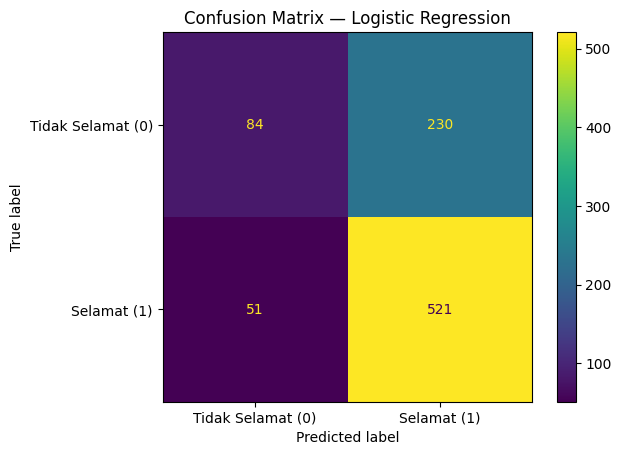

In [44]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Tidak Selamat (0)", "Selamat (1)"]
)

disp.plot()
plt.title("Confusion Matrix — Logistic Regression")
plt.show()

### 6.3 ROC Curve

ROC curve memplot **True Positive Rate** (sumbu y) terhadap **False Positive Rate** (sumbu x) untuk berbagai threshold probabilitas. Garis putus-putus diagonal mewakili tebakan acak. Semakin melengkung ke pojok kiri atas, semakin baik model. **AUC** adalah luas area di bawah kurva.

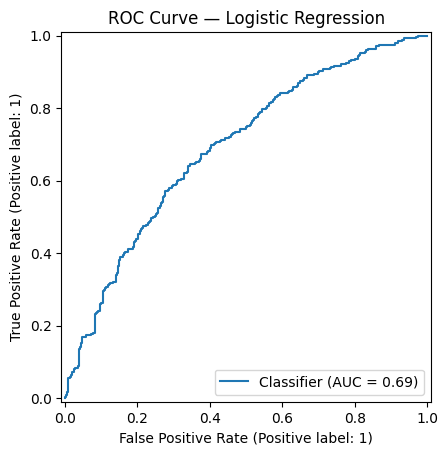

In [45]:
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("ROC Curve — Logistic Regression")
plt.show()

## 7. Interpretasi Koefisien Logistic Regression

Logistic Regression menghasilkan **koefisien** untuk setiap fitur.

- Koefisien **positif** → kenaikan fitur cenderung meningkatkan peluang kelas 1 (**survived_icu = 1**).
- Koefisien **negatif** → kenaikan fitur cenderung menurunkan peluang kelas 1.
- Semakin besar nilai absolut koefisien, semakin kuat pengaruh linear fitur terhadap log-odds target, dengan asumsi fitur lain tetap.

Karena fitur sudah di-**StandardScaler**, besar koefisien dapat dibandingkan dengan lebih masuk akal antarfitur.

In [46]:
lr = model.named_steps["logistic_regression"]

coef = pd.Series(
    lr.coef_[0],
    index=numeric_features
).sort_values()

coef_table = pd.DataFrame({
    "Fitur": coef.index,
    "Koefisien": coef.values,
    "Arah": np.where(coef.values > 0, "Positif", "Negatif")
})

display(coef_table.round(4))

,Fitur,Koefisien,Arah
0,age,-0.4745,Negatif
1,severity_score,-0.3258,Negatif
2,ventilation_required,-0.1391,Negatif
3,chronic_conditions,-0.1131,Negatif
4,creatinine,-0.0563,Negatif
5,systolic_bp,-0.0389,Negatif
6,respiratory_rate,-0.0310,Negatif
7,diastolic_bp,-0.0309,Negatif
8,gender,-0.0175,Negatif
9,heart_rate,0.0019,Positif


#### Visualisasi Koefisien

Koefisien Logistic Regression divisualisasikan menggunakan diagram batang horizontal. Garis vertikal pada nilai nol membantu membedakan koefisien positif dan negatif.

Visualisasi ini memudahkan perbandingan arah dan besar koefisien antarfitur. Nilai koefisien perlu dibaca bersama konteks model dan tidak diartikan sebagai ukuran pengaruh sebab-akibat.

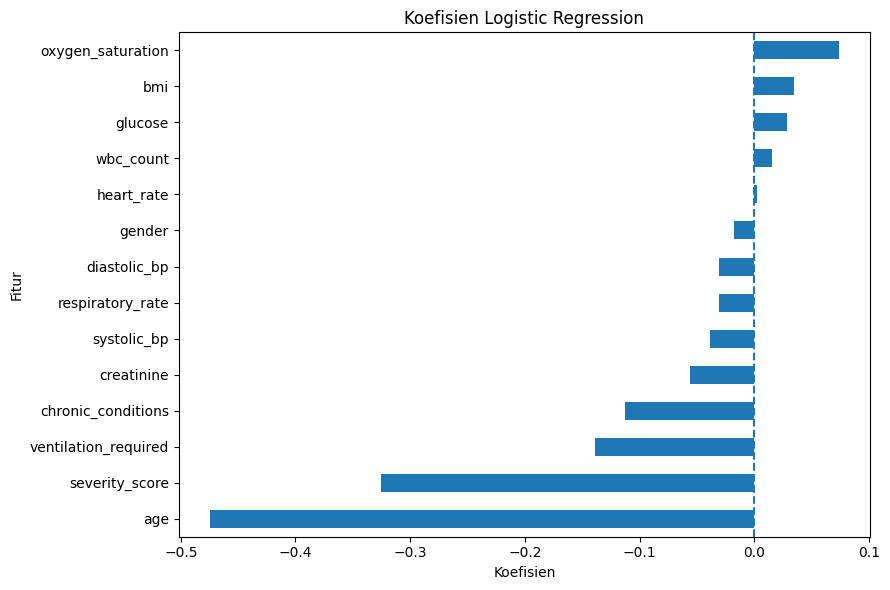

In [47]:
plt.figure(figsize=(9, 6))
coef.sort_values().plot(kind="barh")
plt.axvline(0, linestyle="--")
plt.title("Koefisien Logistic Regression")
plt.xlabel("Koefisien")
plt.ylabel("Fitur")
plt.tight_layout()
plt.show()

### 7.1 Interpretasi Praktis

Interpretasi berikut dibaca dari tanda dan besar koefisien, bukan sebagai hubungan sebab-akibat. Model hanya menemukan pola prediktif pada data.

- Fitur dengan koefisien positif cenderung berkaitan dengan probabilitas **survived_icu = 1** yang lebih tinggi.
- Fitur dengan koefisien negatif cenderung berkaitan dengan probabilitas **survived_icu = 1** yang lebih rendah.
- Fitur dengan koefisien mendekati nol memberikan kontribusi linear yang relatif kecil dalam model.
- **Koefisien bukan bukti bahwa suatu fitur menyebabkan pasien selamat atau tidak selamat.** Ini adalah hubungan prediktif dalam model.

Untuk laporan, gunakan nilai koefisien yang muncul dari output notebook setelah dijalankan sebagai dasar menyebut fitur paling positif dan paling negatif.

In [48]:
top_positive = coef.sort_values(ascending=False).head(5)
top_negative = coef.sort_values().head(5)

print("5 fitur dengan koefisien paling positif:")
display(top_positive.to_frame("Koefisien").round(4))

print("\n5 fitur dengan koefisien paling negatif:")
display(top_negative.to_frame("Koefisien").round(4))

5 fitur dengan koefisien paling positif:


,Koefisien
oxygen_saturation,0.0736
bmi,0.0343
glucose,0.0285
wbc_count,0.0155
heart_rate,0.0019



5 fitur dengan koefisien paling negatif:


,Koefisien
age,-0.4745
severity_score,-0.3258
ventilation_required,-0.1391
chronic_conditions,-0.1131
creatinine,-0.0563


## 8. Perbandingan Logistic Regression Tanpa dan Dengan StandardScaler

Sebagai pembanding sederhana, model baseline hanya melakukan **median imputation**, sedangkan model akhir melakukan **median imputation + StandardScaler**.

Perbandingan ini membantu menunjukkan apakah preprocessing yang digunakan memberikan perubahan performa.

In [49]:
baseline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("logistic_regression", LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])

baseline.fit(X_train, y_train)
baseline_pred = baseline.predict(X_test)
baseline_proba = baseline.predict_proba(X_test)[:, 1]

comparison = pd.DataFrame({
    "Model": ["Baseline", "Logistic Regression + Scaling"],
    "Accuracy": [
        accuracy_score(y_test, baseline_pred),
        accuracy_score(y_test, y_pred)
    ],
    "Precision": [
        precision_score(y_test, baseline_pred, zero_division=0),
        precision
    ],
    "Recall": [
        recall_score(y_test, baseline_pred, zero_division=0),
        recall
    ],
    "F1": [
        f1_score(y_test, baseline_pred, zero_division=0),
        f1
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, baseline_proba),
        roc_auc
    ]
})

display(comparison.round(4))

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Baseline,0.6828,0.6937,0.9108,0.7876,0.6909
1,Logistic Regression + Scaling,0.6828,0.6937,0.9108,0.7876,0.6910


## 9. Kesimpulan

### Temuan Data
Dataset ICU memiliki beberapa masalah kualitas data, terutama **missing value, duplicate, nilai ekstrem/corrupted, outlier, dan inkonsistensi tekanan darah**. Masalah tersebut diperiksa terlebih dahulu sebelum modeling.

### Preprocessing
Cleaning dilakukan dengan membuang duplicate dan corrupted extreme rows serta memperbaiki ketidakkonsistenan tekanan darah. Missing value tidak dibuang seluruhnya karena dapat mengurangi jumlah data; sebagai gantinya, model menggunakan **median imputation**.

### Visualisasi
- **Histogram** digunakan untuk melihat distribusi masing-masing fitur.
- **Heatmap** digunakan untuk melihat korelasi antarvariabel.

### Supervised Learning
Karena target **survived_icu** adalah biner, masalah ini merupakan **binary classification**. Model yang digunakan adalah **Logistic Regression**.

### Interpretasi Model
Koefisien Logistic Regression menunjukkan arah hubungan prediktif setiap fitur terhadap peluang **survived_icu = 1**. Koefisien positif menunjukkan arah positif, sedangkan koefisien negatif menunjukkan arah negatif. Interpretasi harus dibaca sebagai **hubungan prediktif**, bukan hubungan sebab-akibat.

### Evaluasi
Performa model dinilai menggunakan **Accuracy, Precision, Recall, F1-Score, ROC-AUC, confusion matrix, dan ROC curve**. Nilai aktual mengikuti output saat notebook dijalankan.

## 10. Ringkasan Alur

```text
Dataset ICU
    |
Data Understanding
    |
Cek kolom + missing + duplicate + outlier + consistency
    |
Data Cleaning
    |
Histogram + Heatmap
    |
Pisahkan X dan y
    |
Train-Test Split
    |
Median Imputation
    |
Standard Scaling
    |
Logistic Regression
    |
Prediksi
    |
Evaluasi
    |
Interpretasi koefisien
```

**Inti pengerjaan tugas kami:** data yang kotor dibersihkan dan dipersiapkan terlebih dahulu, kemudian digunakan untuk supervised learning dengan Logistic Regression.